In [13]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import lib_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Euler method**

In [14]:
def euler(f_xy, y0, x):
    leny = len(y0) if not np.isscalar(y0) else 1
    sols_y = np.zeros((len(x), leny))
    sols_y[0] = y0
    for i in range(len(x) - 1):
        h = x[i+1] - x[i]
        sols_y[i+1] = sols_y[i] + h * f_xy(x[i], sols_y[i])
    return sols_y

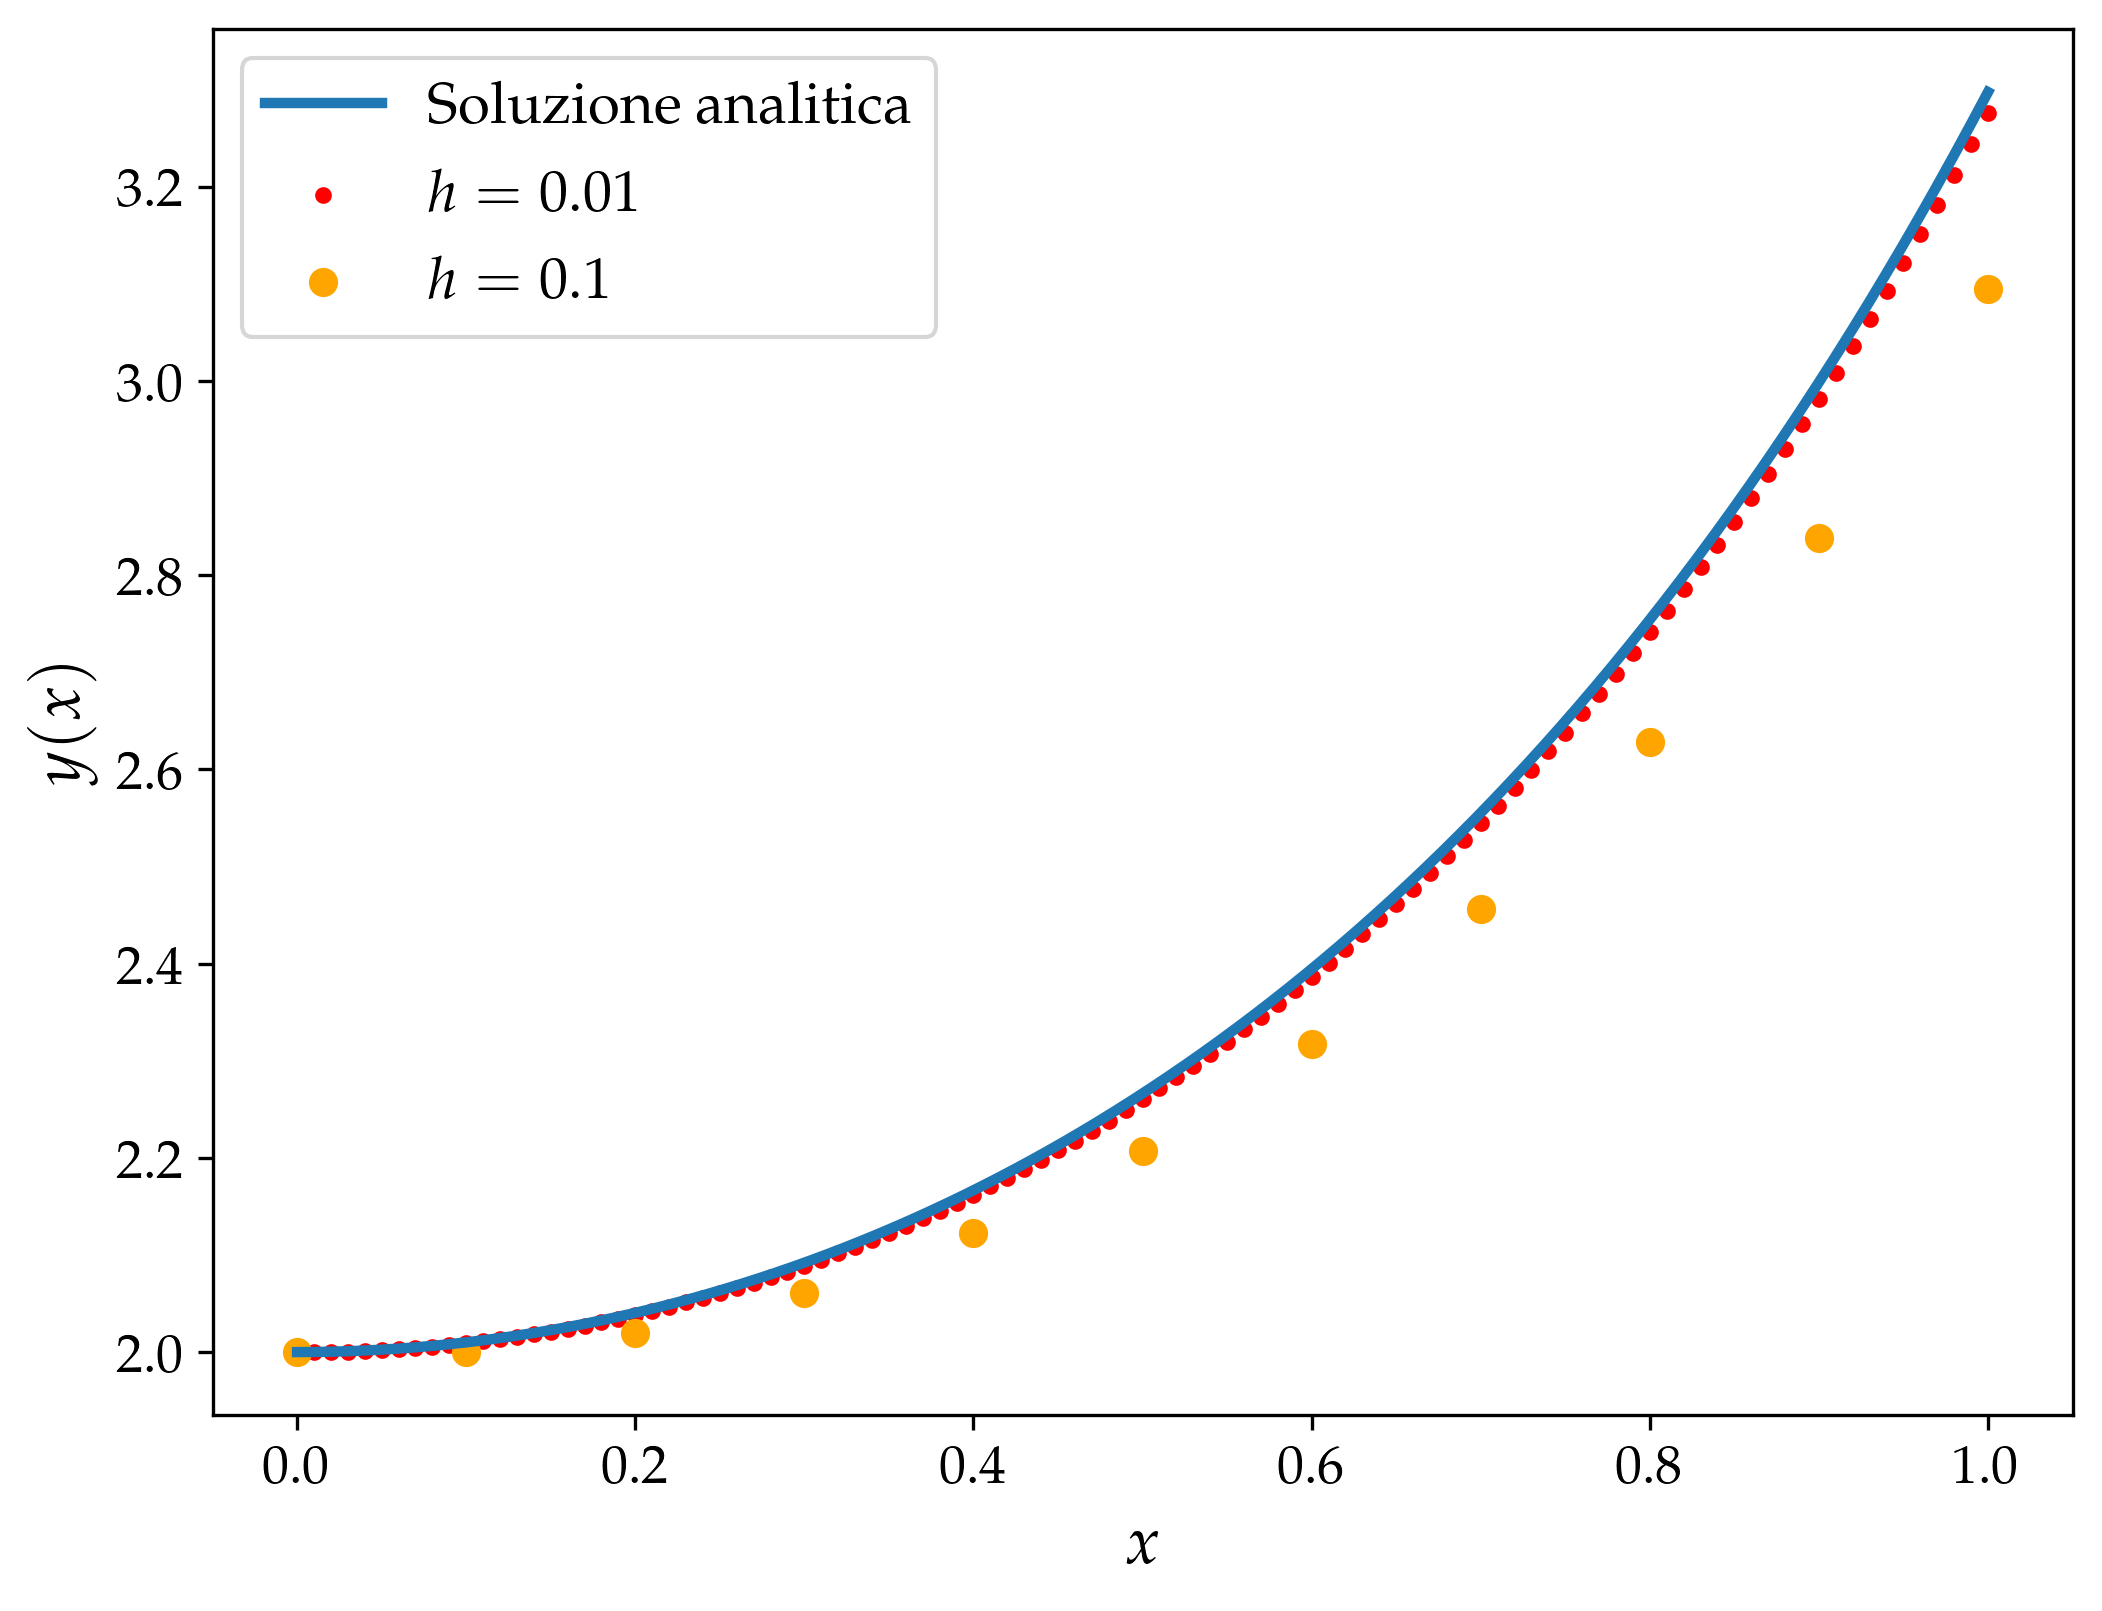

In [15]:
# y'= x*y
# y0 = 2

f_dx = lambda x, y: x * y
y0 = 2
xmax = 1

xcoo = np.linspace(0, xmax, 100)
# analytic sol
ycoo = 2*np.exp(xcoo**2 / 2)
plt.plot(xcoo, ycoo, label='Soluzione analitica', lw=2.5)

for couple in [(0.01, '.', 'red'), (0.1, 'o', 'orange')]:
    h, mar, col = couple
    x_span = np.arange(0, xmax + h, h) 
    res = euler(f_dx, y0, x_span)
    plt.scatter(x_span, res, color=col, marker=mar, label=rf'$h = {h}$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.legend()
plt.savefig('plots/forw_euler.png')
plt.show()

## **Backward Euler method**

In [16]:
def back_euler(f_xy, y0, x):
    from lib_equations import Secant_mth
    leny = len(y0) if not np.isscalar(y0) else 1
    sols = np.zeros((len(x), leny))
    sols[0] = y0
    for i in range(len(x) - 1):
        h = x[i+1] - x[i]
        y = lambda eta_p1: eta_p1 - sols[i] - h*f_xy(x[i+1], eta_p1)
        
        sol = Secant_mth(y, x[i], x[i+1])
        sols[i+1] = sol[0]
    return sols


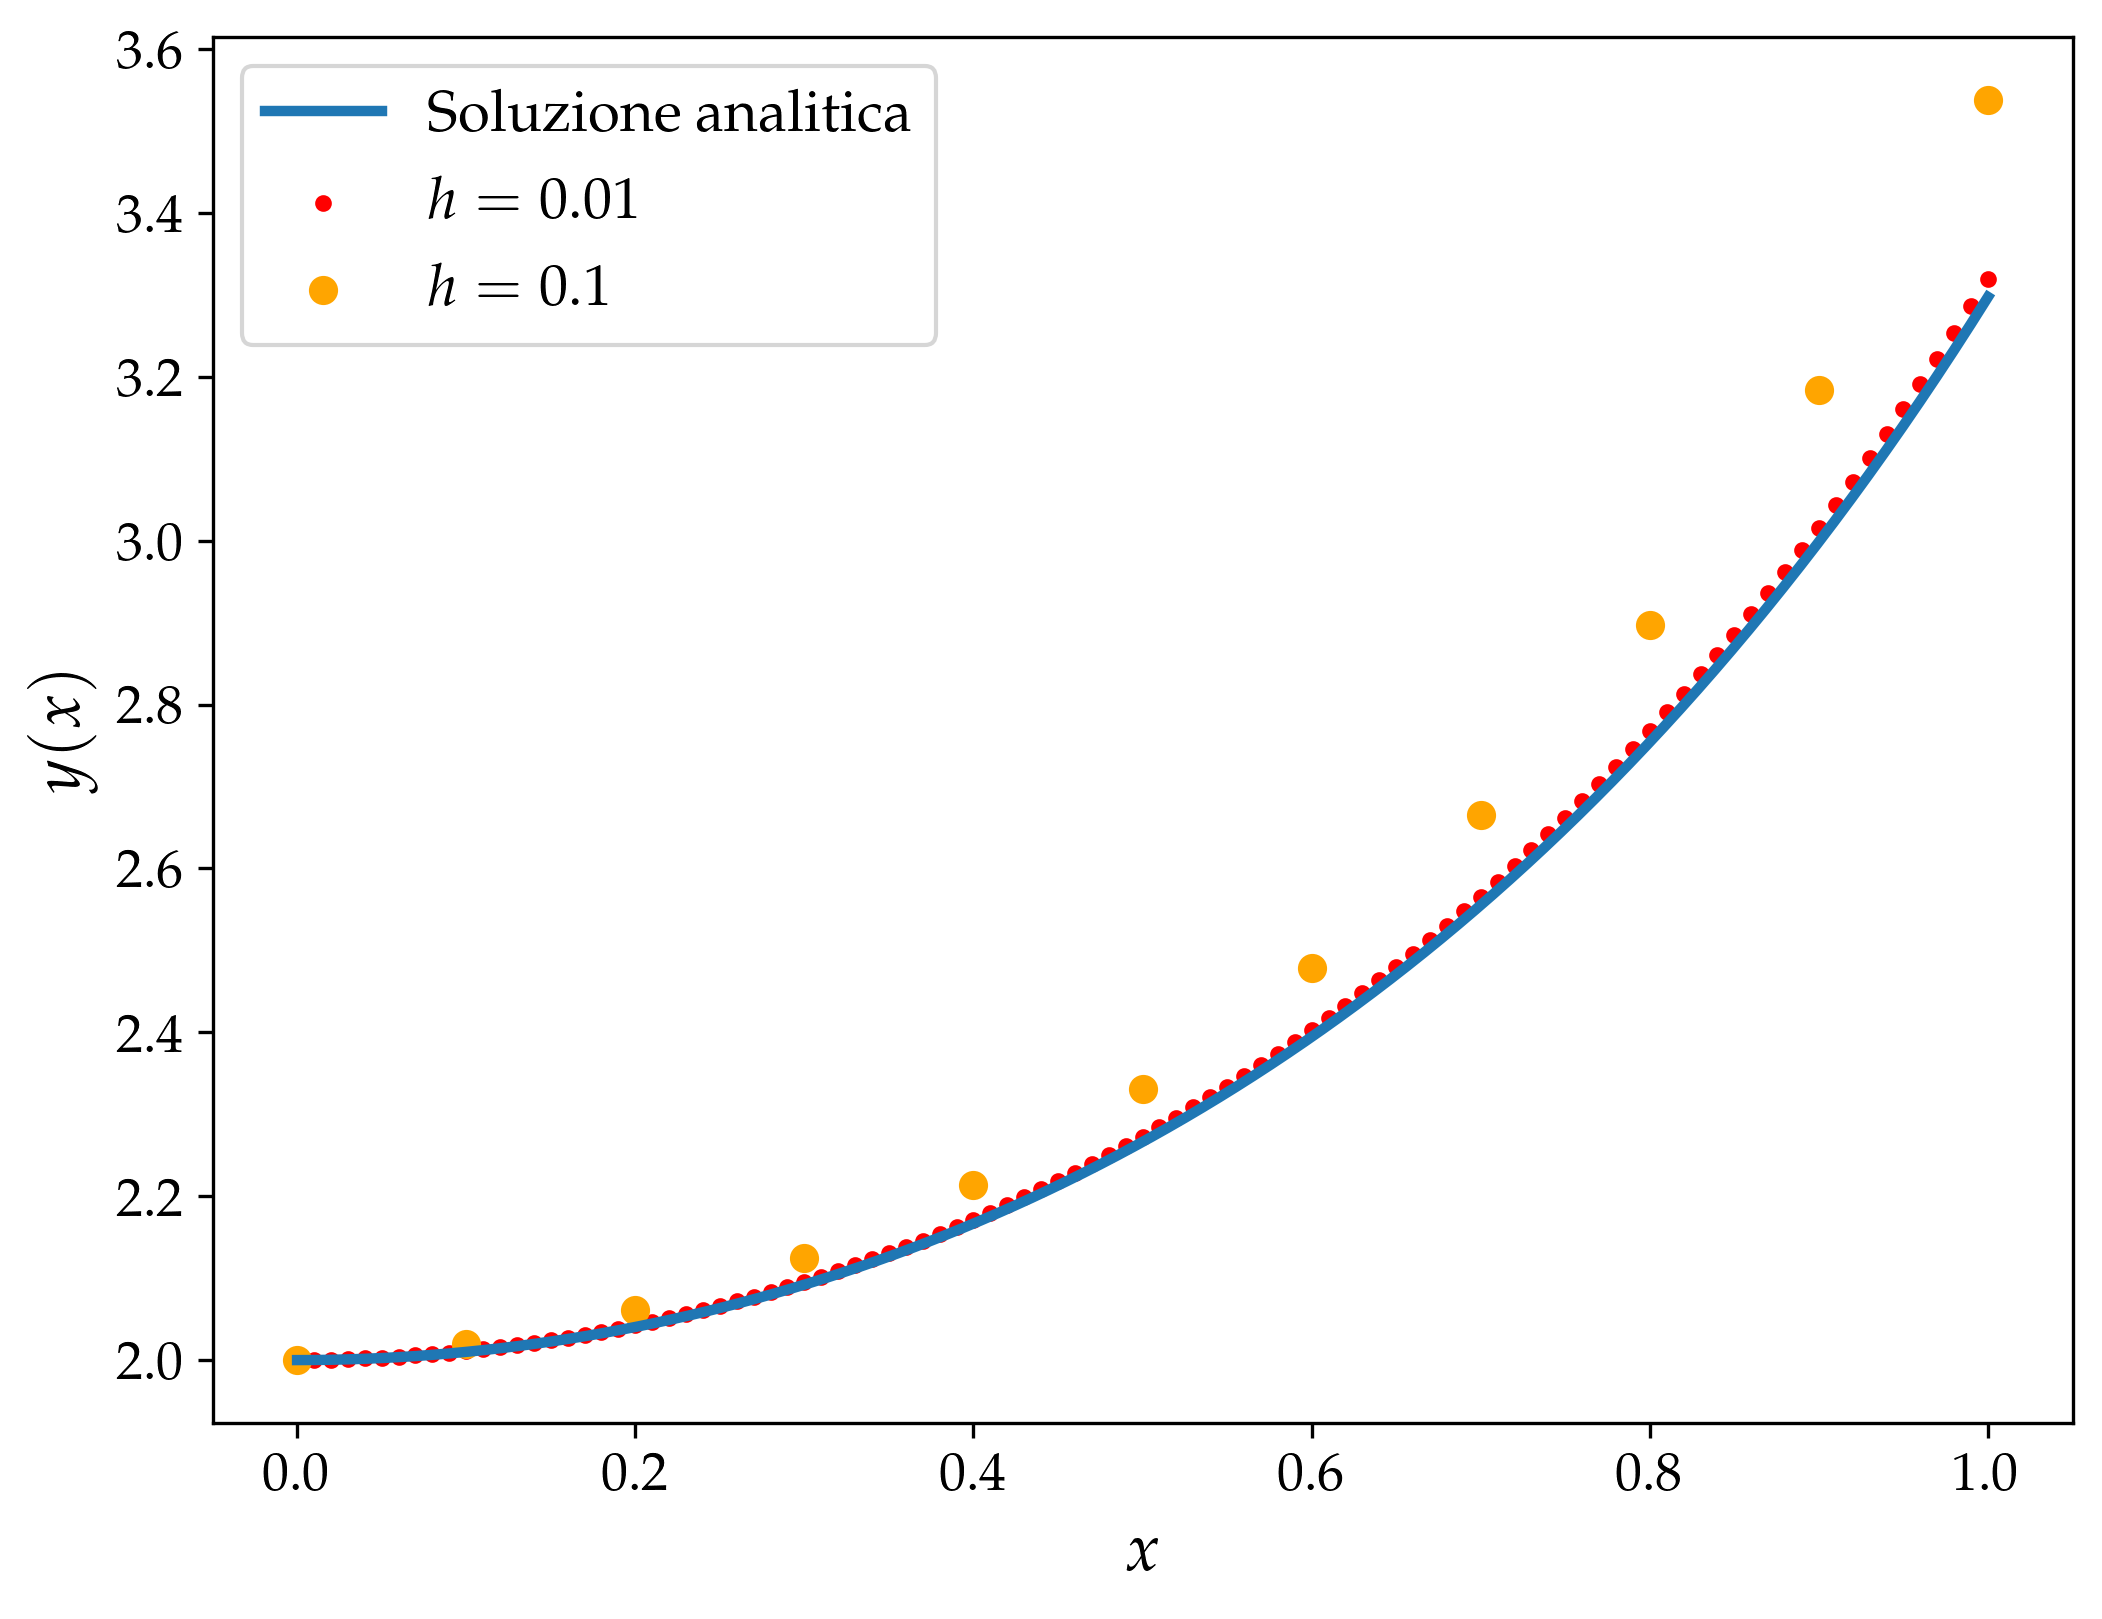

In [17]:

plt.plot(xcoo, ycoo, label='Soluzione analitica', lw=2.5)

for couple in [(0.01, '.', 'red'), (0.1, 'o', 'orange')]:
    h, mar, col = couple
    x_span = np.arange(0, xmax + h, h) 
    res = back_euler(f_dx, y0, x_span)
    plt.scatter(x_span, res, color=col, marker=mar, label=rf'$h = {h}$')

plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.legend()
plt.savefig('plots/back_euler.png')
plt.show()


## **Stability**

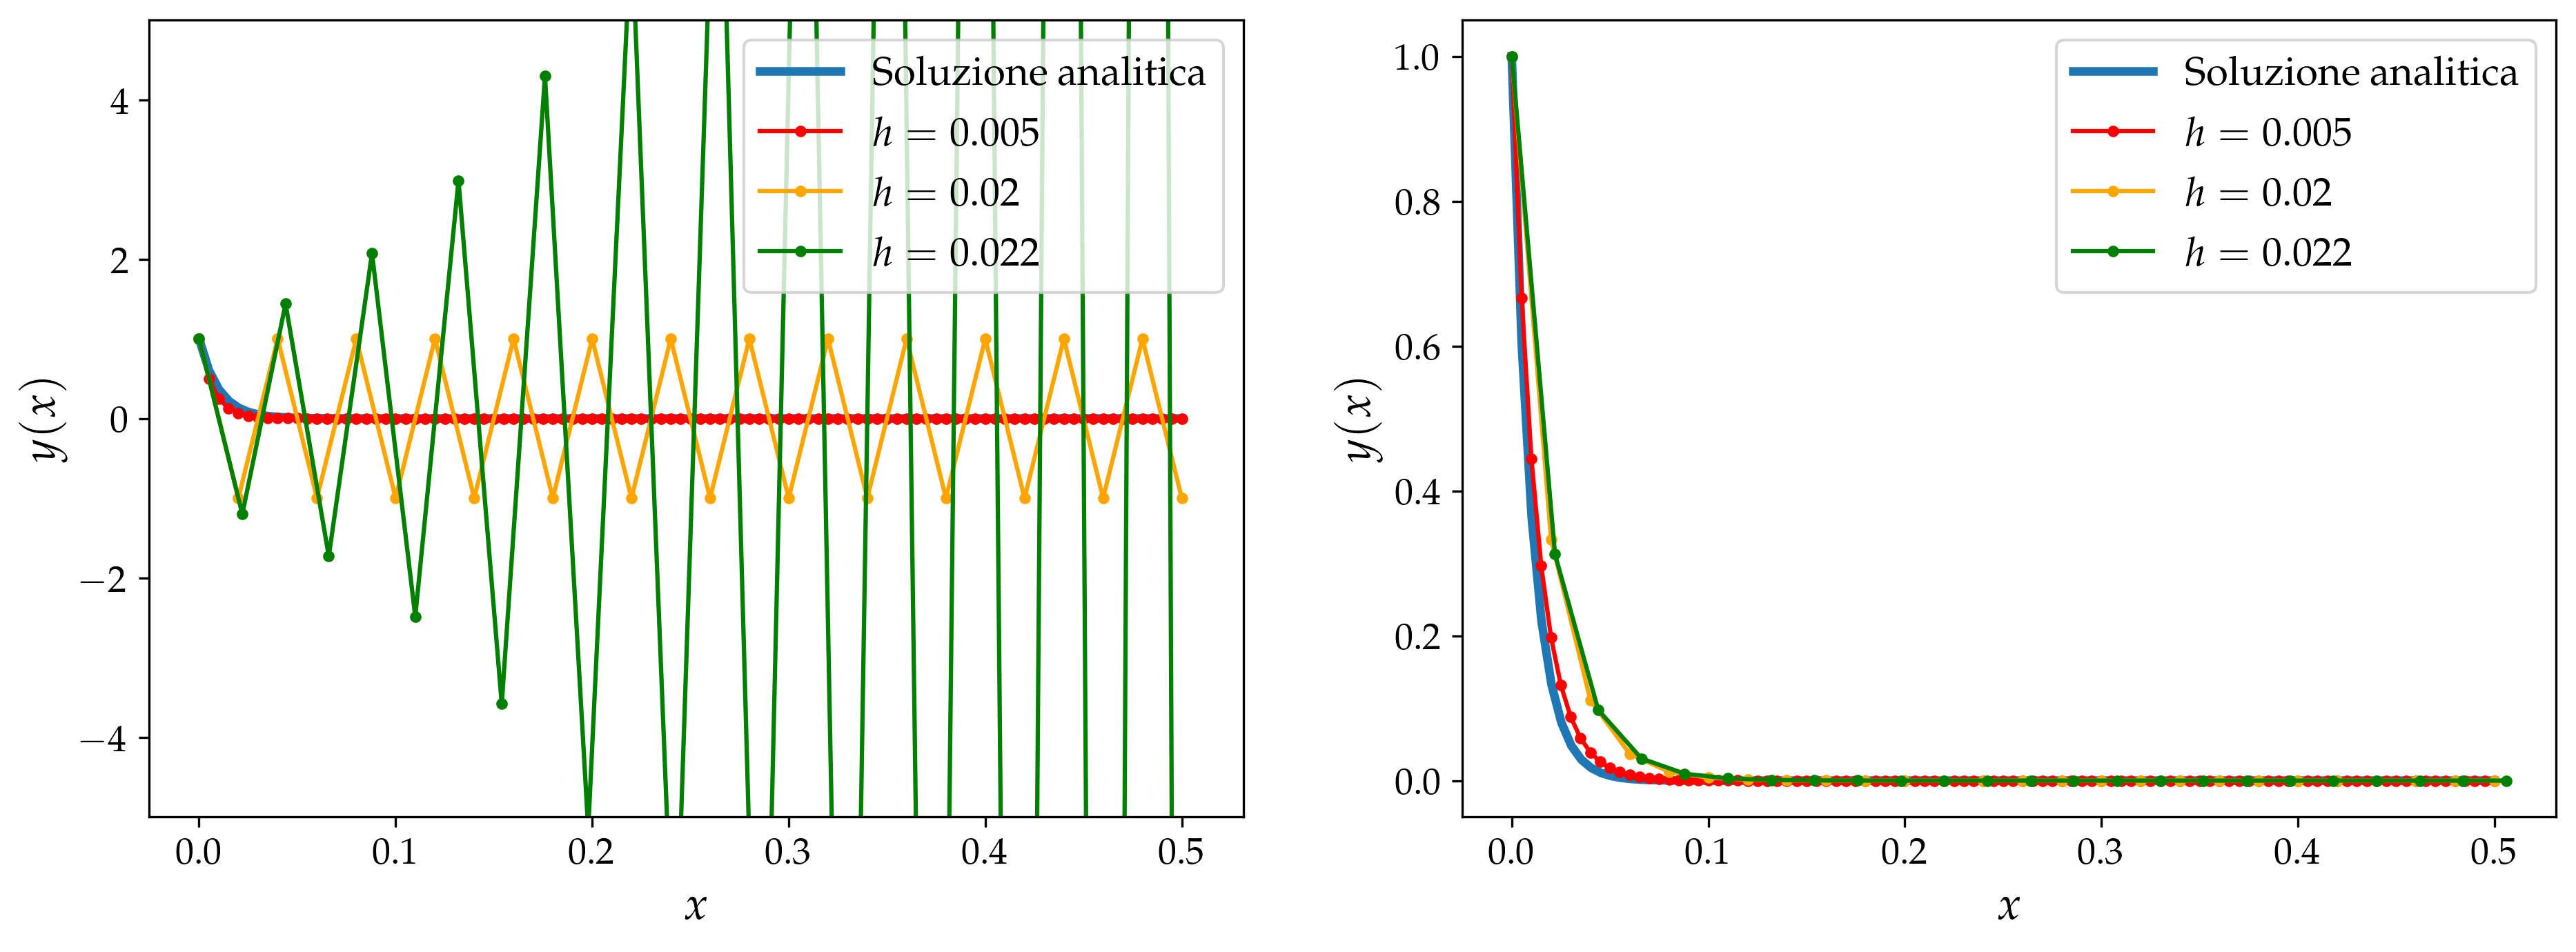

In [18]:
# y' = -100*x
# y0 = 1

f_dx = lambda x, y: -100*y
y0 = 1
xmax = 0.5

xcoo = np.linspace(0, xmax, 100)
# analytic sol
ycoo = np.exp(-100*xcoo)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax1, ax2 = ax
ax1.plot(xcoo, ycoo, label='Soluzione analitica', lw=3)
ax2.plot(xcoo, ycoo, label='Soluzione analitica', lw=3)

for couple in [(0.005, 'red'), (0.02, 'orange'), (0.022, 'green')]:
    h, col = couple
    x_span = np.arange(0, xmax + h, h) 
    res1 = euler(f_dx, y0, x_span)
    res2 = back_euler(f_dx, y0, x_span)
    ax1.plot(x_span, res1, color=col, marker='.', ls='-', label=rf'$h = {h}$')
    ax2.plot(x_span, res2, color=col, marker='.', ls='-', label=rf'$h = {h}$')
for axi in ax:
    axi.set_xlabel(r'$x$')
    axi.set_ylabel(r'$y(x)$')
    axi.legend()
ax1.set_ylim(-5, 5)

plt.savefig('plots/stab_euler.png')
plt.show()